In [19]:
from sklearn.linear_model import LogisticRegression
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
from pathlib import Path
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


classifier_device = torch.device("cpu")

In [11]:
import os

sam_checkpoint = "sam_vit_b_01ec64.pth"
if not os.path.exists(sam_checkpoint):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
        sam_checkpoint
    )
    print("Download complete.")

# Lecture 14 uses vit_b
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)

# FORCE CPU because your CUDA memory is dying
sam_device = torch.device("cpu")
sam = sam.to(sam_device)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=100,
)

print("SAM device:", sam_device)

SAM device: cpu


In [12]:
DATA_DIR = Path("data/raw")
BOTH_DIR = DATA_DIR / "both"
OUTPUT_DIR = Path("outputs/multicat")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED)
np.random.seed(SEED)

def get_image_paths(class_dir: Path):
    paths = []
    for p in class_dir.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            paths.append(p)
    return sorted(paths)

In [13]:
tig_paths = get_image_paths(DATA_DIR / "tig")
buster_paths = get_image_paths(DATA_DIR / "buster")

all_paths = tig_paths + buster_paths
labels = np.array([0] * len(tig_paths) + [1] * len(buster_paths))
label_names = {0: "tig", 1: "buster"}

weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(classifier_device)
feature_extractor.eval()

for param in feature_extractor.parameters():
    param.requires_grad = False

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def encode_images(paths, batch_size=16):
    features = []
    valid_paths = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []

        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
                batch_tensors.append(img_transform(img))
                valid_paths.append(p)
            except Exception as e:
                print(f"Skipping {p}: {e}")

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(classifier_device)

        with torch.no_grad():
            feats = feature_extractor(batch).flatten(1)

        features.append(feats.cpu().numpy())

    return np.vstack(features), valid_paths

X, valid_paths = encode_images(all_paths)
path_to_label = {str(p): y for p, y in zip(all_paths, labels)}
y = np.array([path_to_label[str(p)] for p in valid_paths])

clf = LogisticRegression(max_iter=5000, random_state=SEED)
clf.fit(X, y)

print("Classifier rebuilt.")
print("Feature matrix shape:", X.shape)
print("Tig images:", len(tig_paths))
print("Buster images:", len(buster_paths))

Classifier rebuilt.
Feature matrix shape: (40, 512)
Tig images: 20
Buster images: 20


In [26]:
import re

def natural_key(p):
    return [int(x) if x.isdigit() else x.lower()
            for x in re.split(r'(\d+)', p.stem)]

both_paths = sorted(get_image_paths(BOTH_DIR), key=natural_key)

for i, p in enumerate(both_paths):
    print(i, p.name)

0 both1.jpg
1 both2.jpg
2 both3.jpg
3 both4.jpg
4 both5.jpg
5 both6.jpg
6 both7.jpg
7 both8.jpg
8 both9.jpg
9 both10.jpg
10 both11.jpg


In [14]:
def encode_pil_images(pil_images):
    batch = torch.stack([clip_preprocess(img.convert("RGB")) for img in pil_images]).to(DEVICE)
    with torch.no_grad():
        feats = clip_model.encode_image(batch)
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

def mask_to_box(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()

def extract_candidate_crops(image_pil, sam_masks, min_area=2000, max_frac=0.8):
    img_np = np.array(image_pil)
    H, W = img_np.shape[:2]
    crops = []

    for m in sam_masks:
        binary = m["segmentation"]
        area = m["area"]
        if area < min_area:
            continue

        box = mask_to_box(binary)
        if box is None:
            continue

        x1, y1, x2, y2 = box
        box_area = (x2 - x1 + 1) * (y2 - y1 + 1)
        if box_area > max_frac * H * W:
            continue

        crop = image_pil.crop((x1, y1, x2 + 1, y2 + 1))
        crops.append({
            "crop": crop,
            "box": (x1, y1, x2, y2),
            "mask_area": area
        })

    return crops


In [15]:
def classify_candidate_crops(crops, clf):
    if len(crops) == 0:
        return []

    batch = torch.stack([
        img_transform(c["crop"].convert("RGB")) for c in crops
    ]).to(classifier_device)

    with torch.no_grad():
        X_crops = feature_extractor(batch).flatten(1).cpu().numpy()

    pred_labels = clf.predict(X_crops)
    pred_probs = clf.predict_proba(X_crops)

    results = []
    for crop_info, pred, probs in zip(crops, pred_labels, pred_probs):
        results.append({
            "box": crop_info["box"],
            "crop": crop_info["crop"],
            "pred": label_names[int(pred)],
            "prob_tig": float(probs[0]),
            "prob_buster": float(probs[1]),
            "confidence": float(np.max(probs))
        })

    results = sorted(results, key=lambda x: x["confidence"], reverse=True)
    return results

In [42]:
both_paths = get_image_paths(BOTH_DIR)
print("Both-cat images:", len(both_paths))

if len(both_paths) == 0:
    raise ValueError(f"No both-cat images found in {BOTH_DIR.resolve()}")

image_path = both_paths[0]
print("Using image:", image_path)

image = Image.open(image_path).convert("RGB")
image_np = np.array(image).astype(np.uint8)

# SAM step
sam_masks = mask_generator.generate(image_np)

# turn masks into crops, then classify each crop
crops = extract_candidate_crops(image, sam_masks, min_area=2000)
results = classify_candidate_crops(crops, clf)

img_h, img_w = image_np.shape[:2]
img_area = img_h * img_w

filtered_results = []
for r in results:
    x1, y1, x2, y2 = r["box"]
    box_area = (x2 - x1) * (y2 - y1)
    area_frac = box_area / img_area

    # keep only medium-sized, reasonably confident boxes
    if 0.02 <= area_frac <= 0.20 and r["confidence"] >= 0.80:
        filtered_results.append(r)

print("SAM masks:", len(sam_masks))
print("Candidate crops:", len(crops))
print("Filtered predictions:")
for r in filtered_results[:10]:
    print(r["pred"], round(r["confidence"], 3), r["box"])

tig_results = [r for r in filtered_results if r["pred"] == "tig"]
buster_results = [r for r in filtered_results if r["pred"] == "buster"]

best_results = []

if len(tig_results) > 0:
    best_tig = max(tig_results, key=lambda r: r["confidence"])
    best_results.append(best_tig)

if len(buster_results) > 0:
    best_buster = max(buster_results, key=lambda r: r["confidence"])
    best_results.append(best_buster)

# fallback: if only one class survives, just keep the top 2 filtered boxes
if len(best_results) < 2:
    filtered_results = sorted(filtered_results, key=lambda r: r["confidence"], reverse=True)
    best_results = filtered_results[:2]

results = best_results

print("Best results to plot:")
for r in results:
    print(r["pred"], round(r["confidence"], 3), r["box"])

Both-cat images: 11
Using image: data\raw\both\both1.jpg
SAM masks: 21
Candidate crops: 21
Filtered predictions:
tig 0.992 (np.int64(1225), np.int64(643), np.int64(2140), np.int64(1413))
tig 0.905 (np.int64(554), np.int64(705), np.int64(937), np.int64(1381))
buster 0.853 (np.int64(1381), np.int64(0), np.int64(2798), np.int64(669))
tig 0.819 (np.int64(852), np.int64(0), np.int64(1349), np.int64(686))
Best results to plot:
tig 0.992 (np.int64(1225), np.int64(643), np.int64(2140), np.int64(1413))
buster 0.853 (np.int64(1381), np.int64(0), np.int64(2798), np.int64(669))


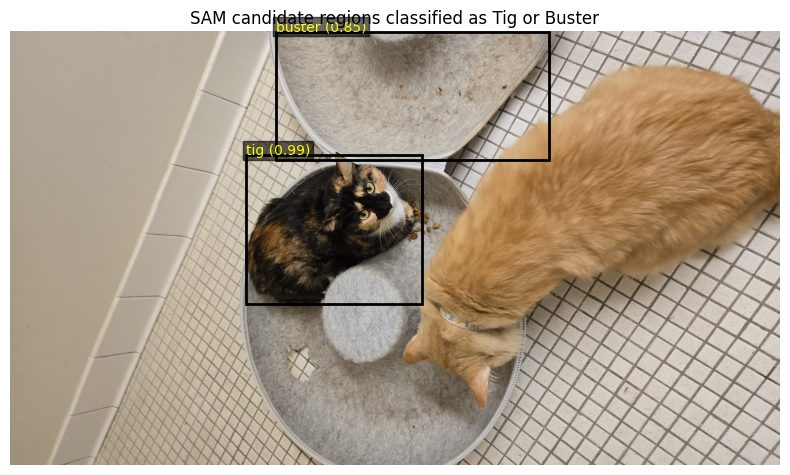

In [43]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image)

for r in results[:6]:
    x1, y1, x2, y2 = r["box"]
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(
        x1, y1 - 5,
        f'{r["pred"]} ({r["confidence"]:.2f})',
        color="yellow",
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.6, pad=2)
    )

ax.set_title("SAM candidate regions classified as Tig or Buster")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "both_cat_labeled_example.png", dpi=200, bbox_inches="tight")
plt.show()

another pic

In [44]:
image_path = BOTH_DIR / "both8.jpg"
print("Using image:", image_path)

image = Image.open(image_path).convert("RGB")
image_np = np.array(image).astype(np.uint8)

sam_masks = mask_generator.generate(image_np)
crops = extract_candidate_crops(image, sam_masks, min_area=2000)
results = classify_candidate_crops(crops, clf)

img_h, img_w = image_np.shape[:2]
img_area = img_h * img_w

filtered_results = []
for r in results:
    x1, y1, x2, y2 = r["box"]
    box_area = (x2 - x1) * (y2 - y1)
    area_frac = box_area / img_area

    if 0.02 <= area_frac <= 0.35:
        filtered_results.append(r)

results = filtered_results

print("SAM masks:", len(sam_masks))
print("Candidate crops:", len(crops))
print("Top predictions:")

tig_results = [r for r in filtered_results if r["pred"] == "tig"]
buster_results = [r for r in filtered_results if r["pred"] == "buster"]

best_results = []

if len(tig_results) > 0:
    best_tig = max(tig_results, key=lambda r: r["confidence"])
    best_results.append(best_tig)

if len(buster_results) > 0:
    best_buster = max(buster_results, key=lambda r: r["confidence"])
    best_results.append(best_buster)

# fallback: if only one class survives, just keep the top 2 filtered boxes
if len(best_results) < 2:
    filtered_results = sorted(filtered_results, key=lambda r: r["confidence"], reverse=True)
    best_results = filtered_results[:2]

results = best_results

print("Best results to plot:")
for r in results:
    print(r["pred"], round(r["confidence"], 3), r["box"])

Using image: data\raw\both\both8.jpg
SAM masks: 39
Candidate crops: 38
Top predictions:
Best results to plot:
tig 0.985 (np.int64(0), np.int64(0), np.int64(997), np.int64(1709))
buster 0.961 (np.int64(3176), np.int64(1550), np.int64(3999), np.int64(2251))


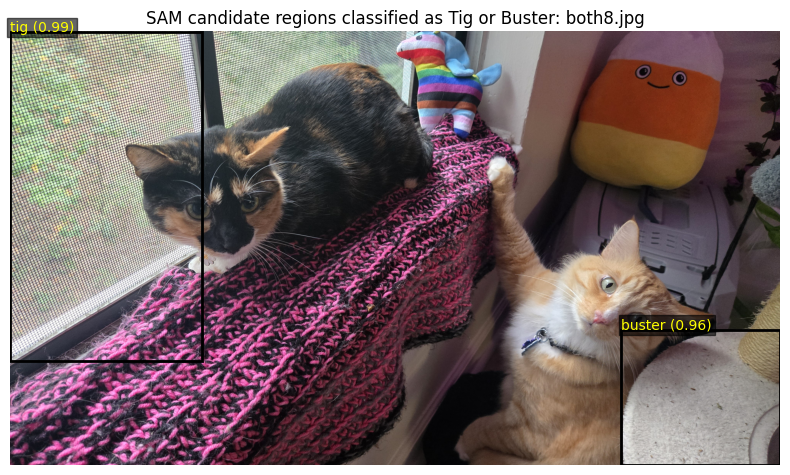

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_np)

for r in results[:6]:
    x1, y1, x2, y2 = r["box"]
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(
        x1,
        max(0, y1 - 5),
        f'{r["pred"]} ({r["confidence"]:.2f})',
        color="yellow",
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.6, pad=2)
    )

ax.set_title(f"SAM candidate regions classified as Tig or Buster: {image_path.name}")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "both8_labeled.png", dpi=200, bbox_inches="tight")
plt.show()